# Propensity Score Stratification (PSS)
Propensity score stratification is simpler, preserves more data, and supports subgroup analysis better than matching—making it a strong choice for large observational studies with good treatment–control overlap.

## Case Study

An urban school district runs an **after-school tutoring program** aimed at improving students' **final exam scores**. The program particularly outreaches to students with lower prior achievement and from lower socioeconomic status (SES). Parents with higher education are somewhat less likely to enroll their children. You want to estimate the causal effect of the tutoring program on final exam performance while adjusting for confounding factors.

* Treatment: participation in the after-school tutoring program (`treatment`, 1 = participated).
* Outcome: final exam score (`final_score`, numeric).
* Observed confounders: prior academic score (`prior_score`), socioeconomic status (`ses` — low/medium/high), parental education (`parent_edu`), hours studied per week (`hours_studied`), and attendance rate (`attendance`).

True data-generating choices:

* The tutoring program has a true additive effect of **+3 points** on final exam score.
* Program participation is more likely for **lower prior_score** and **low SES** students (targeting), and less likely when `parent_edu` is high.
* Outcome depends on prior_score, hours studied, attendance, SES, parental education, and treatment.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel

np.random.seed(2025)
n = 2000  

# Confounders
ses = np.random.choice([0,1,2], size=n, p=[0.35, 0.45, 0.20])
parent_edu = np.random.choice([0,1,2], size=n, p=[0.4, 0.35, 0.25])

# Prior academic score
prior_score_raw = np.random.normal(70, 10, size=n)
prior_score = np.clip(prior_score_raw, 30, 100)

# Hours studied per week
hours_raw = np.random.normal(
    5 + 0.05*(prior_score-70) + 0.8*(parent_edu==2), 2, size=n)
hours_studied = np.clip(hours_raw, 0, 30)

# Attendance
attendance_raw = np.random.normal(
    0.85 + 0.02*(prior_score-70) - 0.04*(ses==0), 0.07, size=n)
attendance = np.clip(attendance_raw, 0.5, 1.0)

# Treatment assignment (logistic model)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

logit = (
    -0.5
    - 0.05*(prior_score - 70)
    + 0.3*(ses == 0)
    - 0.2*(ses == 2)
    - 0.2*(parent_edu == 2))
treatment_prob = sigmoid(logit)
treatment = np.random.binomial(1, treatment_prob, size=n)

# Outcome
true_treatment_effect = 3.0
noise = np.random.normal(0, 4, size=n)
final_score = (
    30
    + 0.45 * prior_score
    + 1.8 * hours_studied
    + 8.0 * attendance
    + 1.5 * (parent_edu == 2)
    - 2.0 * (ses == 0)
    + true_treatment_effect * treatment
    + noise)

# Dataframe
data = pd.DataFrame({
    "ses": ses,
    "parent_edu": parent_edu,
    "prior_score": np.round(prior_score, 2),
    "hours_studied": np.round(hours_studied, 2),
    "attendance": np.round(attendance, 3),
    "treatment": treatment,
    "treatment_prob": np.round(treatment_prob, 3),
    "final_score": np.round(final_score, 2)})

data["ses_label"] = data["ses"].map({0: "low", 1: "medium", 2: "high"})
data["parent_edu_label"] = data["parent_edu"].map({0: "no_college", 1: "some_college", 2: "college_plus"})

## DAG

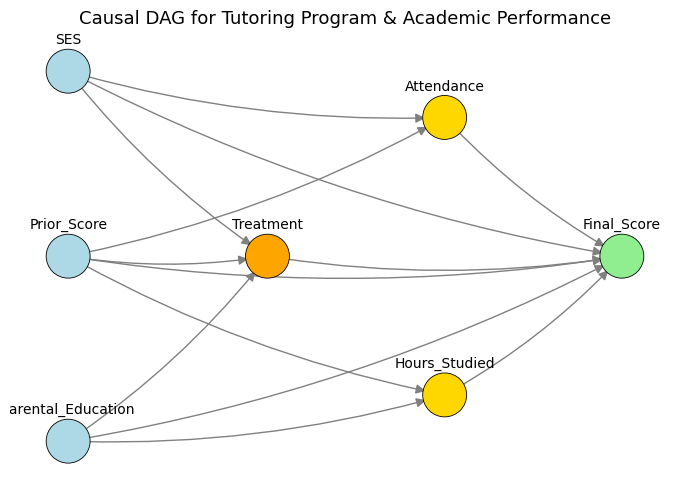

In [72]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
edges = [
    # Confounders → Treatment
    ("SES", "Treatment"),
    ("Parental_Education", "Treatment"),
    ("Prior_Score", "Treatment"),
    # Confounders → Outcome
    ("SES", "Final_Score"),
    ("Parental_Education", "Final_Score"),
    ("Prior_Score", "Final_Score"),
    # Predictors → Outcome
    ("Hours_Studied", "Final_Score"),
    ("Attendance", "Final_Score"),
    # Confounders → Predictors
    ("Prior_Score", "Hours_Studied"),
    ("Parental_Education", "Hours_Studied"),
    ("Prior_Score", "Attendance"),
    ("SES", "Attendance"),
    # Treatment → Outcome
    ("Treatment", "Final_Score"),]
G.add_edges_from(edges)

# Node colors
node_colors = {
    "SES": "lightblue",
    "Parental_Education": "lightblue",
    "Prior_Score": "lightblue",
    "Hours_Studied": "gold",
    "Attendance": "gold",
    "Treatment": "orange",
    "Final_Score": "lightgreen"}

pos = { "SES": (-2.6, 1.2),
        "Parental_Education": (-2.6, -1.2),
        "Prior_Score": (-2.6, 0.0),
        "Treatment": (-0.8, 0.0),
        "Hours_Studied": (0.8, -0.9),
        "Attendance": (0.8, 0.9),
        "Final_Score": (2.4, 0.0)}

# Slight label offset so labels don't sit on node borders
label_pos = {k: (x, y+0.2) for k, (x, y) in pos.items()}
plt.figure(figsize=(7, 5))
nx.draw_networkx_nodes(
    G, pos,
    node_color=[node_colors[node] for node in G.nodes()],
    node_size=1000,
    edgecolors="black",
    linewidths=0.6)
# Draw labels
nx.draw_networkx_labels(G, label_pos, font_size=10)
# Draw directed edges with margins so arrowheads are not covered by nodes
nx.draw_networkx_edges(
    G, pos,
    edgelist=edges,
    edge_color='gray',
    arrows=True,
    arrowstyle='-|>',
    arrowsize=14,
    width=1,
    connectionstyle="arc3,rad=0.08",
    min_source_margin=10, 
    min_target_margin=14   )

plt.title("Causal DAG for Tutoring Program & Academic Performance", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

## EDA

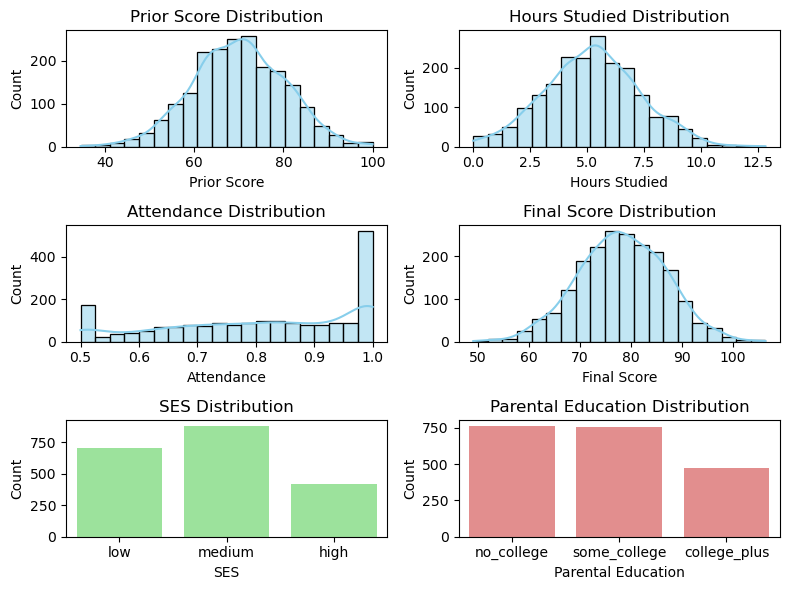

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to plot
numeric_cols = ["prior_score", "hours_studied", "attendance", "final_score"]
categorical_cols = ["ses_label", "parent_edu_label"]

plt.figure(figsize=(8,6))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(data[col], bins=20, kde=True, color="skyblue")
    plt.title(f"{col.replace('_',' ').title()} Distribution")
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel("Count")

plt.subplot(3, 2, 5)  
sns.countplot(
    data=data,
    x="ses_label",
    order=["low","medium","high"],
    color="lightgreen"
)
plt.title("SES Distribution")
plt.xlabel("SES")
plt.ylabel("Count")

plt.subplot(3, 2, 6)  
sns.countplot(
    data=data,
    x="parent_edu_label",
    order=["no_college","some_college","college_plus"],
    color="lightcoral"
)
plt.title("Parental Education Distribution")
plt.xlabel("Parental Education")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## DoWhy - Propensity Score Stratification

### Overall ATE

In [74]:
confounders = ["prior_score", "ses", "parent_edu"]
# Model
model = CausalModel(
    data=data,
    treatment="treatment",
    outcome="final_score",
    common_causes=confounders)
# Identify
identified_estimand = model.identify_effect()
# Estimate
ate_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_stratification",
    target_units="ate")
ci = ate_estimate.get_confidence_intervals(method="bootstrap", num_simulations=100)
print("Estimated ATE:", ate_estimate.value)
print("95% Confidence Interval:", ate_estimate.get_confidence_intervals())

Estimated ATE: 2.6172790111025432
95% Confidence Interval: (1.802860370587303, 3.2802414350675724)


In [75]:
# Placebo Treatment Refuter
ref_placebo = model.refute_estimate(
    identified_estimand, ate_estimate, method_name="placebo_treatment_refuter"
)
print("\nRefute: Placebo treatment\n", ref_placebo)

# Random/Common Cause Refuter
ref_random_cc = model.refute_estimate(
    identified_estimand, ate_estimate, method_name="random_common_cause"
)
print("\nRefute: Random common cause\n", ref_random_cc)

# Bootstrap Refuter
ref_boot = model.refute_estimate(
    identified_estimand, ate_estimate, method_name="bootstrap_refuter", num_simulations=200
)
print("\nRefute: Bootstrap\n", ref_boot)

# Data Subset Refuter
ref_subset_ols = model.refute_estimate(
    identified_estimand,
    ate_estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8,      # use 80% of data in each simulation
    num_simulations=100,      # how many random subsets to try
    random_state=42           # for reproducibility
)
print("\nRefute: Data Subset (OLS)\n", ref_subset_ols)


Refute: Placebo treatment
 Refute: Use a Placebo Treatment
Estimated effect:2.6172790111025432
New effect:0.00655850451093155
p value:0.92


Refute: Random common cause
 Refute: Add a random common cause
Estimated effect:2.6172790111025432
New effect:2.6172790111025432
p value:1.0


Refute: Bootstrap
 Refute: Bootstrap Sample Dataset
Estimated effect:2.6172790111025432
New effect:2.682621761992394
p value:0.9299999999999999


Refute: Data Subset (OLS)
 Refute: Use a subset of data
Estimated effect:2.6172790111025432
New effect:3.0121015348090383
p value:0.0



### CATEs

In [76]:
confounders = ["prior_score", "ses", "parent_edu"]

def estimate_effect_subgroup(df, subgroup_condition, target_units="ate"):
    df_sub = df.loc[subgroup_condition].copy()
    
    # Skip very small subgroups
    treated_count = df_sub['treatment'].sum()
    untreated_count = len(df_sub) - treated_count
    min_per_group = 5
    if treated_count < min_per_group or untreated_count < min_per_group:
        return np.nan, (np.nan, np.nan)

    # Model
    model = CausalModel(
        data=df_sub,
        treatment="treatment",
        outcome="final_score",
        common_causes=confounders)
    
    # Identify
    identified_estimand = model.identify_effect()
    
    # Estimate
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_stratification",
        method_params={"num_strata": 2, "clipping_threshold": min_per_group},
        target_units=target_units)
    
    # Bootstrap confidence intervals
    ci = estimate.get_confidence_intervals(method="bootstrap", num_simulations=100)
    return estimate.value, ci

ses_labels = ["low", "medium", "high"]
parent_labels = ["no_college", "some_college", "college_plus"]

results = []
for ses in ses_labels:
    for parent in parent_labels:
        cond = (data["ses_label"] == ses) & (data["parent_edu_label"] == parent)
        
        ate, ate_ci = estimate_effect_subgroup(data, cond, target_units="ate")
        att, att_ci = estimate_effect_subgroup(data, cond, target_units="att")
        
        results.append({
            "SES": ses,
            "Parental_Education": parent,
            "CATE_Group": f"{ses}-{parent}",  # Explicit CATE label
            "ATE": ate,
            "ATE_CI_Lower": ate_ci[0],
            "ATE_CI_Upper": ate_ci[1],
            "ATT": att,
            "ATT_CI_Lower": att_ci[0],
            "ATT_CI_Upper": att_ci[1]})

results_df = pd.DataFrame(results).round(2)
results_df

,SES,Parental_Education,CATE_Group,ATE,ATE_CI_Lower,ATE_CI_Upper,ATT,ATT_CI_Lower,ATT_CI_Upper
0,low,no_college,low-no_college,1.82,0.58,3.16,1.38,-0.01,2.81
1,low,some_college,low-some_college,1.79,0.24,2.98,1.50,-0.18,2.62
2,low,college_plus,low-college_plus,1.49,-0.74,3.74,1.93,-0.12,4.89
3,medium,no_college,medium-no_college,2.69,1.78,4.55,2.89,1.48,4.56
4,medium,some_college,medium-some_college,1.52,0.07,3.21,1.21,-0.46,3.09
5,medium,college_plus,medium-college_plus,2.56,0.76,5.39,2.13,0.85,4.33
6,high,no_college,high-no_college,2.67,0.55,4.86,2.73,0.35,5.25
7,high,some_college,high-some_college,3.77,2.01,7.04,3.76,2.00,6.67
8,high,college_plus,high-college_plus,1.80,-1.78,4.15,1.66,-1.80,3.72


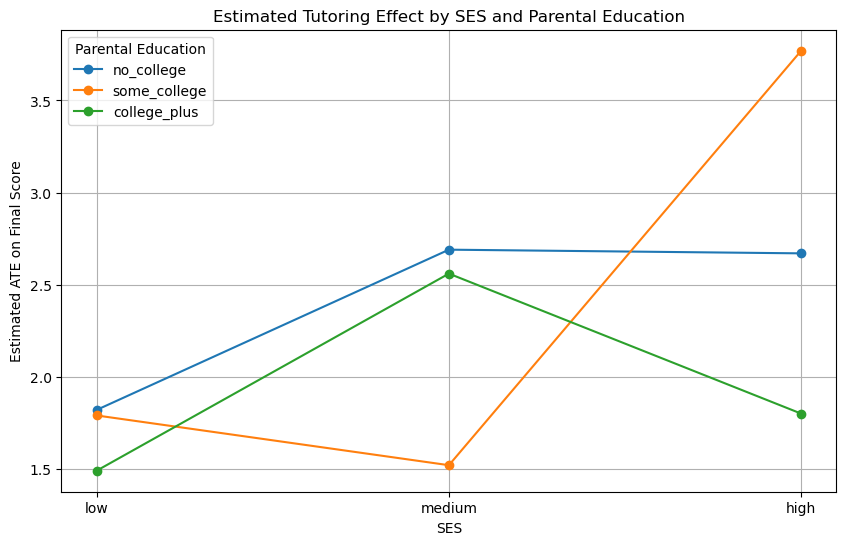

In [77]:
plt.figure(figsize=(10,6))

for parent in parent_labels:
    subset = results_df[results_df["Parental_Education"]==parent]
    plt.plot(subset["SES"], subset["ATE"], marker='o', label=parent)

plt.xlabel("SES")
plt.ylabel("Estimated ATE on Final Score")
plt.title("Estimated Tutoring Effect by SES and Parental Education")
plt.legend(title="Parental Education")
plt.grid(True)
plt.show()

## Manual PSS 

In [78]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Select confounders
confounders = ["prior_score", "ses", "parent_edu"]

# One-hot encode ses and parent_edu
data_encoded = pd.get_dummies(data[confounders], columns=["ses", "parent_edu"], drop_first=True)

# Propensity score
ps_model = LogisticRegression()
ps_model.fit(data_encoded, data["treatment"])

# Add propensity scores to original dataframe
data["propensity_score"] = ps_model.predict_proba(data_encoded)[:,1]

# Into strata
data["ps_stratum"] = pd.qcut(data["propensity_score"], q=5, labels=False)

### Estimated ATE by Propensity Score Stratum

In [79]:
strata_results = []

for s in sorted(data["ps_stratum"].unique()):
    subset = data[data["ps_stratum"] == s]
    min_ps = subset['propensity_score'].min()
    max_ps = subset['propensity_score'].max()
    treated_count = subset[subset["treatment"]==1]["final_score"].count()
    control_count = subset[subset["treatment"]==0]["final_score"].count()
    treated_mean = subset[subset["treatment"]==1]["final_score"].mean()
    control_mean = subset[subset["treatment"]==0]["final_score"].mean()
    ate = treated_mean - control_mean
    strata_results.append({
        "Stratum": s,
        "Min_PS":min_ps,
        "Max_PS":max_ps,
        "Treated_Count": treated_count,
        "Control_Count": control_count,
        "Treated_Mean": treated_mean,
        "Control_Mean": control_mean,
        "ATE": ate
    })

strata_df = pd.DataFrame(strata_results).round(2)
strata_df

,Stratum,Min_PS,Max_PS,Treated_Count,Control_Count,Treated_Mean,Control_Mean,ATE
0,0,0.07,0.27,86,314,88.87,86.10,2.78
1,1,0.27,0.34,132,268,84.04,80.69,3.35
2,2,0.34,0.43,132,268,80.24,76.84,3.40
3,3,0.43,0.52,196,204,75.84,74.17,1.67
4,4,0.52,0.84,246,154,70.15,68.85,1.30


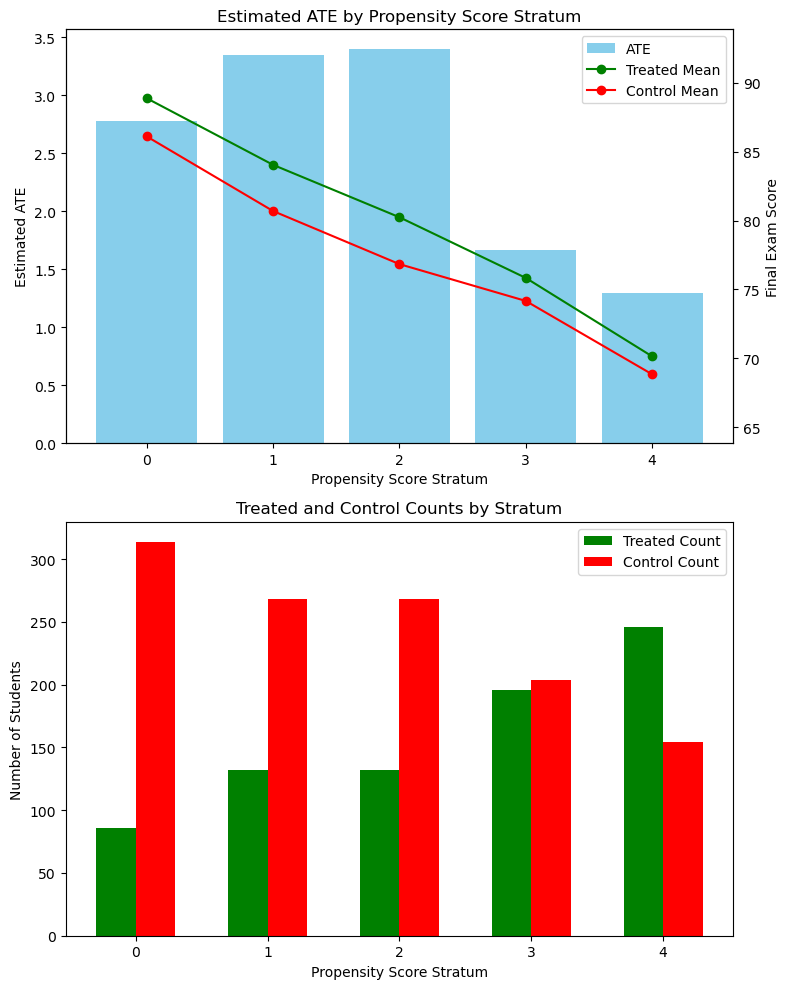

In [80]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,10))

# Plot ATE bars
ax1.bar(strata_df["Stratum"], strata_df["ATE"], color="skyblue", label="ATE")
ax1.set_xlabel("Propensity Score Stratum")
ax1.set_ylabel("Estimated ATE")
ax1.set_xticks(strata_df["Stratum"])

# Secondary axis for Treated/Control means
ax1b = ax1.twinx()
ax1b.plot(strata_df["Stratum"], strata_df["Treated_Mean"], marker='o', color='green', label='Treated Mean')
ax1b.plot(strata_df["Stratum"], strata_df["Control_Mean"], marker='o', color='red', label='Control Mean')
ax1b.set_ylabel("Final Exam Score")
ax1b.set_ylim(min(strata_df["Control_Mean"])-5, max(strata_df["Treated_Mean"])+5)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1b.get_legend_handles_labels()
ax1b.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

ax1.set_title("Estimated ATE by Propensity Score Stratum")
# plot: Treated & Control Counts
ax2.bar(strata_df["Stratum"]-0.15, strata_df["Treated_Count"], width=0.3, color='green', label='Treated Count')
ax2.bar(strata_df["Stratum"]+0.15, strata_df["Control_Count"], width=0.3, color='red', label='Control Count')
ax2.set_xlabel("Propensity Score Stratum")
ax2.set_ylabel("Number of Students")
ax2.set_xticks(strata_df["Stratum"])
ax2.legend()
ax2.set_title("Treated and Control Counts by Stratum")

plt.tight_layout()
plt.show()

### Diagnostics (Standardized Mean Differences)

['prior_score', 'ses_1', 'ses_2', 'parent_edu_1', 'parent_edu_2']


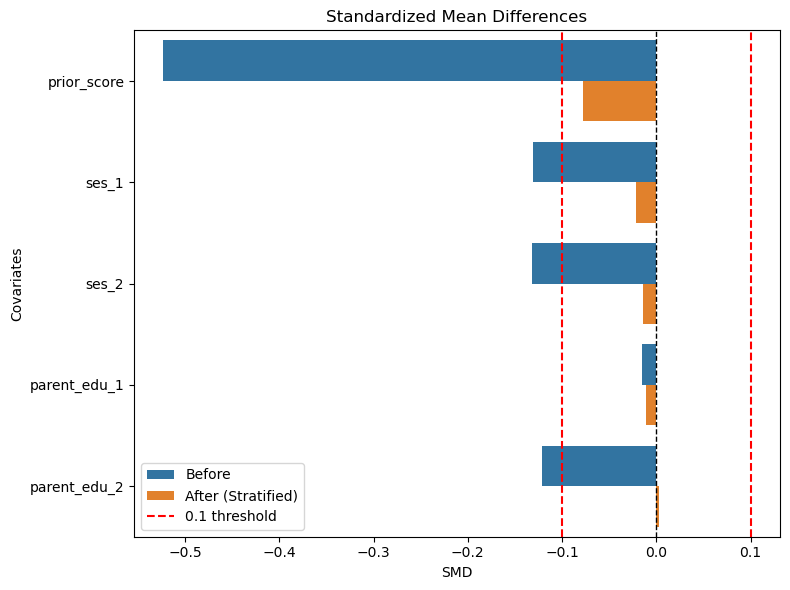

In [81]:
# List of encoded covariates for SMD calc
encoded_covariates = list(data_encoded.columns)
print(encoded_covariates)
# SMDs
def smd(df, treat_col, cov_col):
    """
    Standardized mean difference for continuous/dummy covariate (unweighted).
    """
    x1 = df[df[treat_col] == 1][cov_col].astype(float)
    x0 = df[df[treat_col] == 0][cov_col].astype(float)
    m1, m0 = x1.mean(), x0.mean()
    v1, v0 = x1.var(ddof=1), x0.var(ddof=1)
    return (m1 - m0) / np.sqrt((v1 + v0) / 2)

def smd_stratified(df, treat_col, cov_col, stratum_col):
    """
    compute SMD within each stratum and average across strata.
    """
    smds = []
    for _, dfs in df.groupby(stratum_col):
        smds.append(smd(dfs, treat_col, cov_col))
    return np.mean(smds)

records = []
for cov in encoded_covariates:
    dtmp = data.copy()
    dtmp[cov] = data_encoded[cov]
    
    # Before (raw sample)
    records.append({
        "Covariate": cov,
        "Stage": "Before",
        "SMD": smd(dtmp, "treatment", cov)  })

    # After (stratified)
    records.append({
        "Covariate": cov,
        "Stage": "After (Stratified)",
        "SMD": smd_stratified(dtmp, "treatment", cov, "ps_stratum")   })

smd_summary = pd.DataFrame(records)
before_df = smd_summary[smd_summary["Stage"] == "Before"].reset_index(drop=True)
after_df = smd_summary[smd_summary["Stage"] == "After (Stratified)"].reset_index(drop=True)

# Plot
smd_df = pd.concat([before_df, after_df], ignore_index=True)
plt.figure(figsize=(8, 6))
sns.barplot(data=smd_df, x='SMD', y='Covariate', hue='Stage')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0.1, color='red', linestyle='--', label='0.1 threshold')
plt.axvline(-0.1, color='red', linestyle='--')
plt.title('Standardized Mean Differences')
plt.xlabel('SMD')
plt.ylabel('Covariates')
plt.legend()
plt.tight_layout()
plt.show()